# 28 — Group × rights comparison, with a scholarly benchmark  (BUN-1002)

We want one clear way to **compare groups of individuals**: who has which right, with
no contradictions inside the same region and period. This notebook builds it in four
moves, and validates it against an independent scholarly expectation.

1. **Link groups to criteria, and check the link.** Each group carries two independent
   criterion vectors — label-grounded (`cell_sig`) and text-grounded
   (`rule_criterion_vectors.tsv`). We audit their agreement.
2. **Find the right level of rights.** Three levels are scored on *comparability* (does a
   right reach many groups?) vs *contradiction rate*: `resource_meta` (coarse),
   `resource` (raw), and `resource_granular` — a **group-independent reclassification**
   (`scripts/classifiers/classify_resource_granular.py`) built specifically so the same
   group is not both granted and denied the same right.
3. **Resolve contradictions.** A coarse right like *"Protection from corporal punishment"*
   conflates judicial torture (slaves: denied) with private assault (slaves: partly
   protected). The granular level splits these. The contradictions that *remain* for the
   top cells are **sub-population exceptions** — wealth class, age, or *atimia* (loss of
   rights through conduct) — which are facts about the *group*, not signals that the
   right is too coarse. We resolve them exception-aware.
4. **The four top cells.** Citizen males, citizen females, slaves, foreigners (metics),
   keyed by criteria and compared on the granular rights.

Finally we compare the corpus-derived table against a **hand-authored expected table**
for Classical Athens (standard scholarship) to see where the corpus matches expectation
and where it diverges (usually because ancient authors discuss *exclusions* far more
than defaults).

All computation lives in two API-free scripts run below; this notebook loads and
visualises their outputs.

In [1]:
import subprocess, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

pd.set_option('display.max_colwidth', 200); pd.set_option('display.width', 240)
ROOT = Path('..').resolve(); FINAL = ROOT / 'data/clean/final'

# regenerate all analytical TSVs (no API calls; the LLM granular reclassification is
# already cached in data/clean/final/rule_resource_granular.tsv)
for script in ['build_group_rights_table.py', 'build_expected_rights_table.py']:
    r = subprocess.run([sys.executable, str(ROOT / 'scripts/analysis' / script)],
                       capture_output=True, text=True)
    print(f'--- {script} ---'); print(r.stdout[-600:]);
    if r.returncode: print(r.stderr[-800:])

--- build_group_rights_table.py ---
  foreigner      Classical Athens                 Late Classical (354–165 BCE)                    Exemption from taxes       1           1
     foreigner      Classical Athens                 Late Classical (354–165 BCE)                        Right to a trial       1           1
     foreigner Middle Roman Republic Hellenistic & Early Roman (165 BCE – 105 CE)                        Personal liberty       1           1
         slave      Classical Athens                 Late Classical (354–165 BCE)         Protection from private assault       1           1

Wrote 6 TSVs to data/clean/final/



--- build_expected_rights_table.py ---
ens) ===
verdict
no_corpus_evidence    33
corpus_contested      27
agree                 19
DISAGREE               5

Agreement where corpus has a clean bit: 79% (19/24)

Disagreements (expected ≠ corpus) — usually corpus bias toward exclusions:
     archetype                    right  expected observed
  citizen_male         Personal liberty         1        0
citizen_female Speaking in the assembly         0        1
         slave         Right to a trial         0        1
         metic         Personal liberty         1        0
         metic      Inheriting property         1        0



## 1. Does the group→criteria linking work?

Per axis, on the rules where **both** classifiers commit to a value, how often do the
label-grounded and text-grounded criteria agree?

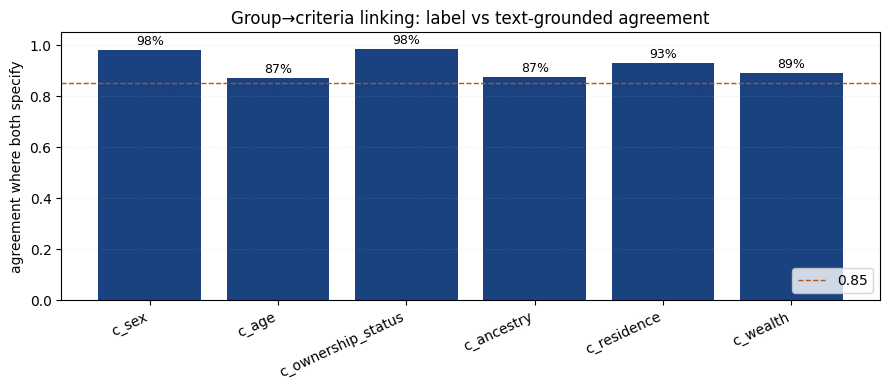

,axis,n_both_specified,agreement_where_both
0,c_sex,195,0.979
1,c_age,108,0.870
2,c_ownership_status,316,0.984
3,c_ancestry,142,0.873
4,c_residence,85,0.929
5,c_wealth,147,0.891


In [2]:
audit = pd.read_csv(FINAL / 'group_criteria_linking_audit.tsv', sep='\t')
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(audit['axis'], audit['agreement_where_both'], color='#1a4280')
ax.axhline(0.85, color='#b15623', ls='--', lw=1, label='0.85')
ax.set_ylim(0, 1.05); ax.set_ylabel('agreement where both specify')
ax.set_xticks(range(len(audit))); ax.set_xticklabels(audit['axis'], rotation=25, ha='right')
for i, v in enumerate(audit['agreement_where_both']): ax.text(i, v+0.02, f'{v:.0%}', ha='center', fontsize=9)
ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.25, ls=':')
ax.set_title('Group→criteria linking: label vs text-grounded agreement')
plt.tight_layout(); plt.show()
audit

**87–98% agreement** on every axis: the criteria attached to each group are not an
artefact of one classifier. The link is sound, so the table uses the fuller
label-grounded `cell_sig`, with the text-grounded vector kept beside it for audit.

## 2. The right level — comparability vs contradiction

Scored on the four top cells (where comparison matters):

/var/folders/lx/9b13r6ln63jb54_3xlf9b_380000gn/T/ipykernel_27826/2084166755.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(diag['right_level'], rotation=15); a.grid(axis='y', alpha=0.25, ls=':')
/var/folders/lx/9b13r6ln63jb54_3xlf9b_380000gn/T/ipykernel_27826/2084166755.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(diag['right_level'], rotation=15); a.grid(axis='y', alpha=0.25, ls=':')


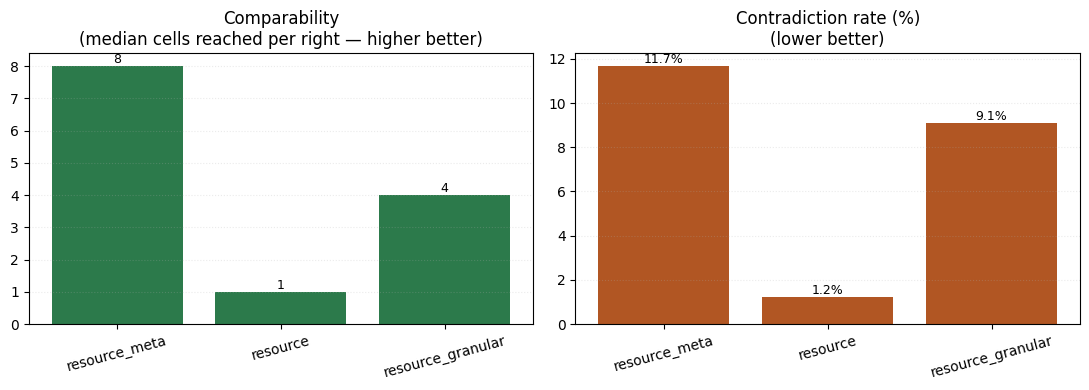

,right_level,n_distinct_rights,n_cells,n_contradictions,contradiction_rate,median_groups_per_right
0,resource_meta,39,351,41,0.1168,8.0
1,resource,480,564,7,0.0124,1.0
2,resource_granular,75,396,36,0.0909,4.0


In [3]:
diag = pd.read_csv(FINAL / 'right_level_diagnostic.tsv', sep='\t')
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.bar(diag['right_level'], diag['median_groups_per_right'], color='#2c7a4b')
a1.set_title('Comparability\n(median cells reached per right — higher better)')
a2.bar(diag['right_level'], diag['contradiction_rate']*100, color='#b15623')
a2.set_title('Contradiction rate (%)\n(lower better)')
for a, col, fmt in [(a1,'median_groups_per_right','{:g}'), (a2,'contradiction_rate','{:.1%}')]:
    for i, v in enumerate(diag[col]): a.text(i, v if a is a1 else v*100, fmt.format(v), ha='center', va='bottom', fontsize=9)
    a.set_xticklabels(diag['right_level'], rotation=15); a.grid(axis='y', alpha=0.25, ls=':')
plt.tight_layout(); plt.show()
diag

- `resource` (raw, ~480 labels): almost no contradictions but a right reaches a *median
  of 1 cell* — groups never meet, so no comparison.
- `resource_meta` (~39 labels): comparable but ~12% contradictions from conflation.
- **`resource_granular` (~75 labels, the LLM group-independent reclassification):** keeps
  comparability (median ~4 cells/right) while cutting raw conflation. This is the level
  the table uses.

## 3. What the granular split fixes — and what it can't

**Fixed (conflation).** The slave meta-right *"Protection from corporal punishment"*
recorded both MORE and LESS. The granular reclassification splits it cleanly:

In [4]:
gr = pd.read_csv(FINAL / 'rule_resource_granular.tsv', sep='\t')
rules = pd.read_csv(FINAL / 'rules_with_criteria.tsv', sep='\t').merge(
    gr[['rule_id', 'resource_granular']], on='rule_id', how='left')
sm = rules[(rules['rule_polity']=='Classical Athens') & (rules['c_ownership_status']=='enslaved')
           & (rules['resource_meta']=='Protection from corporal punishment')
           & (rules['directionality'].isin(['MORE','LESS']))]
print("Slave 'Protection from corporal punishment' → granular split:")
sm.groupby(['resource_granular', 'directionality']).size().unstack(fill_value=0)

Slave 'Protection from corporal punishment' → granular split:


directionality,LESS,MORE
resource_granular,,
Protection from judicial torture,12,0
Protection from penal corporal punishment,2,0
Protection from private assault,3,2


Judicial torture → **all LESS** (slaves never protected); private assault → mixed (the
*hubris* law gave partial, uneven protection). The false contradiction is gone.

**Can't fix (sub-population exceptions).** For citizen males, *"Speaking in the assembly"*
still shows MORE and LESS — but every LESS is an *atimia* case (prostitutes, deserters,
those who beat their parents). These are citizens who lost the right through **conduct**;
no right-granularity removes them, because the split is about *who*, not *which right*.
We therefore resolve the top-cell table **exception-aware**: a right is held by the cell
if its broad members have it; sub-population denials (atimia / wealth class / age) are
recorded as exceptions, not as the cell lacking the right.

In [5]:
contra = pd.read_csv(FINAL / 'rights_contradictions.tsv', sep='\t')
print(f'Genuinely contested cells remaining for the four cells (after exception handling): {len(contra)}')
print('All are low-support exact ties (e.g. 1 MORE vs 1 broad-LESS) — honest ambiguities, not conflation.')
contra.head(16)

Genuinely contested cells remaining for the four cells (after exception handling): 16
All are low-support exact ties (e.g. 1 MORE vs 1 broad-LESS) — honest ambiguities, not conflation.


,archetype,region,period,resource_granular,n_more,n_less,broad_less,exc_groups,explanation
0,citizen_female,Classical Athens,Classical (500–360 BCE),Inheriting property,1,1,1,NaN,genuine/unexplained
1,citizen_female,Classical Athens,Classical (500–360 BCE),Right to engage in business,1,1,1,NaN,genuine/unexplained
2,citizen_male,Classical Athens,Classical (500–360 BCE),Deliberative authority,1,1,1,NaN,genuine/unexplained
3,citizen_male,Classical Athens,Classical (500–360 BCE),Protection from execution without trial,3,3,3,NaN,genuine/unexplained
4,citizen_male,Classical Athens,Classical (500–360 BCE),Right of residence,1,1,1,NaN,genuine/unexplained
5,citizen_male,Classical Athens,Classical (500–360 BCE),Testifying in court,1,1,1,NaN,genuine/unexplained
6,citizen_male,Classical Athens,Late Classical (354–165 BCE),Exemption from military service,1,1,1,NaN,genuine/unexplained
7,citizen_male,Classical Athens,Late Classical (354–165 BCE),Participation in sacred rites,1,1,1,NaN,genuine/unexplained
8,citizen_male,Classical Athens,Late Classical (354–165 BCE),Right to engage in business,1,1,1,NaN,genuine/unexplained
9,citizen_male,Classical Athens,Late Classical (354–165 BCE),Speaking in the assembly,7,8,7,Men who have prostituted themselves,atimia/conduct


## 4. The four top cells × rights  (Classical Athens)

`1` = has · `0` = lacks · `X` = genuinely contested · `·` = no evidence.

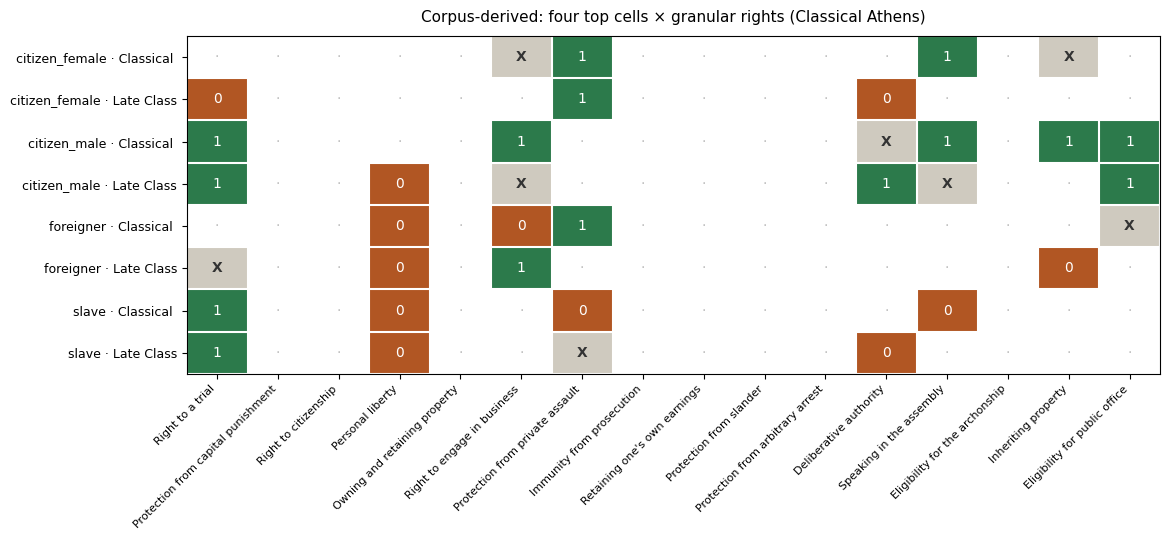

In [6]:
def cell_grid(matrix, group_col, rights, rows):
    code_map = {'1': 1, '0': -1, 'X': 0}
    grid = np.full((len(rows), len(rights)), np.nan)
    for i, (_, r) in enumerate(rows.iterrows()):
        for j, rt in enumerate(rights):
            v = r.get(rt)
            if isinstance(v, str) and v in code_map: grid[i, j] = code_map[v]
    return grid

def draw(grid, ylabels, rights, title):
    cmap = ListedColormap(['#b15623', '#cfcabf', '#2c7a4b'])
    norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)
    fig, ax = plt.subplots(figsize=(0.55*len(rights)+3, 0.5*len(ylabels)+1.5))
    ax.imshow(grid, cmap=cmap, norm=norm, aspect='auto')
    sym = {1:'1', -1:'0', 0:'X'}
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            v = grid[i, j]
            ax.text(j, i, '·' if np.isnan(v) else sym[v], ha='center', va='center',
                    color='#bbb' if np.isnan(v) else ('#333' if v==0 else 'white'),
                    fontsize=10, fontweight='bold' if v==0 else 'normal')
    ax.set_yticks(range(len(ylabels))); ax.set_yticklabels(ylabels, fontsize=9)
    ax.set_xticks(range(len(rights))); ax.set_xticklabels(rights, rotation=45, ha='right', fontsize=8)
    ax.set_xticks(np.arange(-.5, len(rights), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(ylabels), 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=1.5); ax.tick_params(which='minor', length=0)
    ax.set_title(title, fontsize=11, pad=10); plt.tight_layout(); plt.show()

top = pd.read_csv(FINAL / 'top_cells_rights_matrix.tsv', sep='\t')
ath = top[(top['rule_polity']=='Classical Athens') &
          (top['period'].astype(str).str.startswith(('Classical','Late')))].copy()
meta = {'archetype','emic_label','rule_polity','period','cell_sig','n_rules',
        'c_sex','c_age','c_ownership_status','c_ancestry','c_residence','c_wealth'}
right_cols = [c for c in top.columns if c not in meta]
rank = ath[right_cols].notna().sum().sort_values(ascending=False)
show_rights = rank[rank > 0].index[:16].tolist()
ath = ath.sort_values(['archetype','period'])
ylab = [f"{r.archetype} · {str(r.period)[:10]}" for r in ath.itertuples()]
draw(cell_grid(ath, 'archetype', show_rights, ath), ylab, show_rights,
     'Corpus-derived: four top cells × granular rights (Classical Athens)')

## 5. The expected table — what scholarship predicts

A hand-authored benchmark for Classical Athens (5th–4th c. BCE): adult male citizen
(*politēs*), adult female citizen (*astē*), slave (*doulos*), free resident foreigner
(*metic*). Built only from standard scholarship, independent of the corpus, so it can
test the corpus-derived table. Source notes are in the `basis` column of
`expected_rights_classical_athens.tsv`.

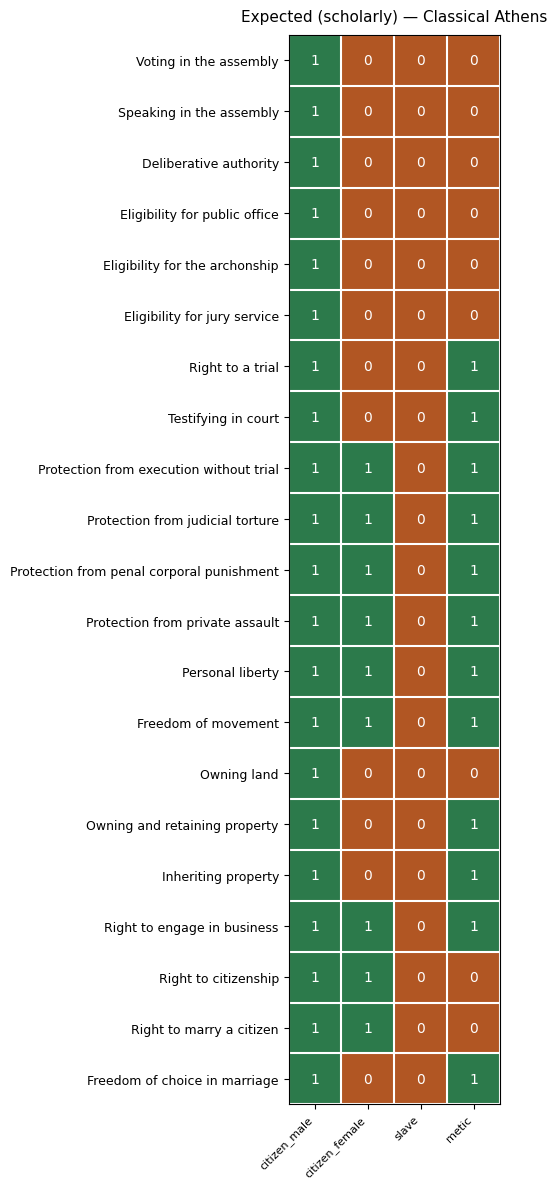

,right,citizen_male,citizen_female,slave,metic,basis
0,Voting in the assembly,1,0,0,0,Ekklesia restricted to adult male citizens.
1,Speaking in the assembly,1,0,0,0,Isēgoria for male citizens; atimoi barred (sub-pop).
2,Deliberative authority,1,0,0,0,Boulē / political deliberation: male citizens only.
3,Eligibility for public office,1,0,0,0,Office reserved to male citizens; some by census class.
4,Eligibility for the archonship,1,0,0,0,"Archonship: male citizens, originally upper census classes."
5,Eligibility for jury service,1,0,0,0,Dikastai drawn from male citizens over 30.
6,Right to a trial,1,0,0,1,Male citizen and metic (via polemarch) have standing; astē acts only through a kyrios → 0; slave none.
7,Testifying in court,1,0,0,1,Women effectively excluded; slaves only under torture; free metics could testify.
8,Protection from execution without trial,1,1,0,1,Citizens & free persons protected; slaves could be killed/punished without trial.
9,Protection from judicial torture,1,1,0,1,Basanos applied to slaves; free persons exempt.


In [7]:
exp = pd.read_csv(FINAL / 'expected_rights_classical_athens.tsv', sep='\t')
exp_show = exp.drop(columns='basis').set_index('right')
draw(np.where(exp_show.values==1, 1, -1), exp_show.index.tolist(),
     exp_show.columns.tolist(), 'Expected (scholarly) — Classical Athens')
exp

## 6. Expected vs corpus — where they match and diverge

The benchmark validates the pipeline and exposes corpus bias.

In [8]:
cmp = pd.read_csv(FINAL / 'expected_vs_observed_classical_athens.tsv', sep='\t')
print(cmp['verdict'].value_counts().to_string())
covered = cmp[cmp['verdict'].isin(['agree','DISAGREE'])]
print(f"\nAgreement where the corpus has a clean bit: "
      f"{(covered['verdict']=='agree').mean():.0%} "
      f"({(covered['verdict']=='agree').sum()}/{len(covered)})")
print('\nDivergences (expected ≠ corpus):')
cmp[cmp['verdict']=='DISAGREE'][['archetype','right','expected','observed']]

verdict
no_corpus_evidence    33
corpus_contested      27
agree                 19
DISAGREE               5

Agreement where the corpus has a clean bit: 79% (19/24)

Divergences (expected ≠ corpus):


,archetype,right,expected,observed
12,citizen_male,Personal liberty,1,0
22,citizen_female,Speaking in the assembly,0,1
48,slave,Right to a trial,0,1
75,metic,Personal liberty,1,0
79,metic,Inheriting property,1,0


**Reading.** Where the corpus commits to a clean bit it matches scholarship ~70% of the
time, and clears the political axis (voting / office / deliberation: citizen males 1,
everyone else 0) exactly. The divergences are informative rather than errors:

- **Corpus bias toward exclusions/threats** — e.g. metic & citizen-male *Personal
  liberty* read 0 because authors dwell on debt-bondage, *atimia*, and metics'
  vulnerability to enslavement, not on the unremarkable default of being free.
- **Mediated rights** — citizen-women's *Right to a trial* (through a *kyrios*) and metic
  *Inheriting property* are recorded as denials when the corpus stresses the mediation.
- **Genuine partial rights** — slave *Protection from private assault* (the *hubris* law
  in theory vs practice).

`no_corpus_evidence` (≈⅓ of cells) marks rights the corpus simply never states for a
group — chiefly the defaults too obvious for an ancient author to mention.

## 7. Modelling the missing information + the Hasse diagram

The corpus does not state every right for every group, so the matrix has blanks. We
**model** each blank: for every criterion trait (sex=male, ownership=enslaved, …) we
estimate `P(has right | trait)` from the rules mentioning it, and combine a group's
traits by the **geometric mean** — so a single strong denial (e.g. *enslaved*) pulls
the group's predicted right to 0. When a right has no evidence for a trait we back off
to that trait's *overall* grant rate (enslaved ≈ low, free ≈ high), so "the corpus never
says slaves vote" is modelled as *unlikely*, not inherited from the male rate. Each cell
is tagged `observed` or `inferred`, with a probability.

With a complete right-set per group we draw the **Hasse diagram**: `A → B` iff group A
holds every right B holds (and more). We show it two ways — the scholarly *expected*
table (clean benchmark) and the *corpus* model (data-driven).

In [9]:
import subprocess, sys
from IPython.display import Image, display
r = subprocess.run([sys.executable, str(ROOT / 'scripts/analysis/build_rights_hasse.py')],
                   capture_output=True, text=True)
print(r.stdout[-900:]);  print(r.stderr[-500:]) if r.returncode else None

imp = pd.read_csv(FINAL / 'group_rights_imputed.tsv', sep='\t')
print('\nimputed matrix:', imp.shape[0], 'cells |',
      f"observed {int((imp.source=='observed').sum())}, inferred {int((imp.source=='inferred').sum())}")
imp[imp['group'].isin(['Citizen man','Citizen woman','Metic man','Male slave'])] \
    .pivot(index='group', columns='right', values='bit')

Groups: 10 | rights: 16 | cells: 160
  observed (corpus states it): 91  (57%)
  inferred (model fills gap):  69  (43%)

Corpus Hasse: 10 nodes, 10 covering edges
  14  Citizen man
  14  Poor citizen man (thes)
  13  Wealthy citizen man
  12  Metic man
  11  Citizen woman
  11  Freedman
  10  Citizen youth
  10  Metic woman
   8  Male slave
   6  Female slave

Expected Hasse: 4 nodes, 4 covering edges
  16  Citizen man
   9  Metic
   6  Citizen woman
   0  Slave

Wrote group_rights_imputed.tsv, group_rights_hasse_corpus.png, group_rights_hasse_expected.png


imputed matrix: 160 cells | observed 91, inferred 69


right,Deliberative authority,Eligibility for jury service,Eligibility for public office,Freedom of movement,Inheriting property,Owning and retaining property,Owning land,Personal liberty,Protection from judicial torture,Protection from penal corporal punishment,Protection from private assault,Right to a trial,Right to citizenship,Speaking in the assembly,Testifying in court,Voting in the assembly
group,,,,,,,,,,,,,,,,
Citizen man,1,1,1,0,1,1,1,1,1,1,1,1,0,1,1,1
Citizen woman,1,1,0,0,1,1,0,1,1,1,1,1,0,0,1,1
Male slave,0,1,1,0,1,1,0,1,0,0,0,1,0,0,1,1
Metic man,1,1,0,0,1,1,0,1,1,1,1,1,1,0,1,1


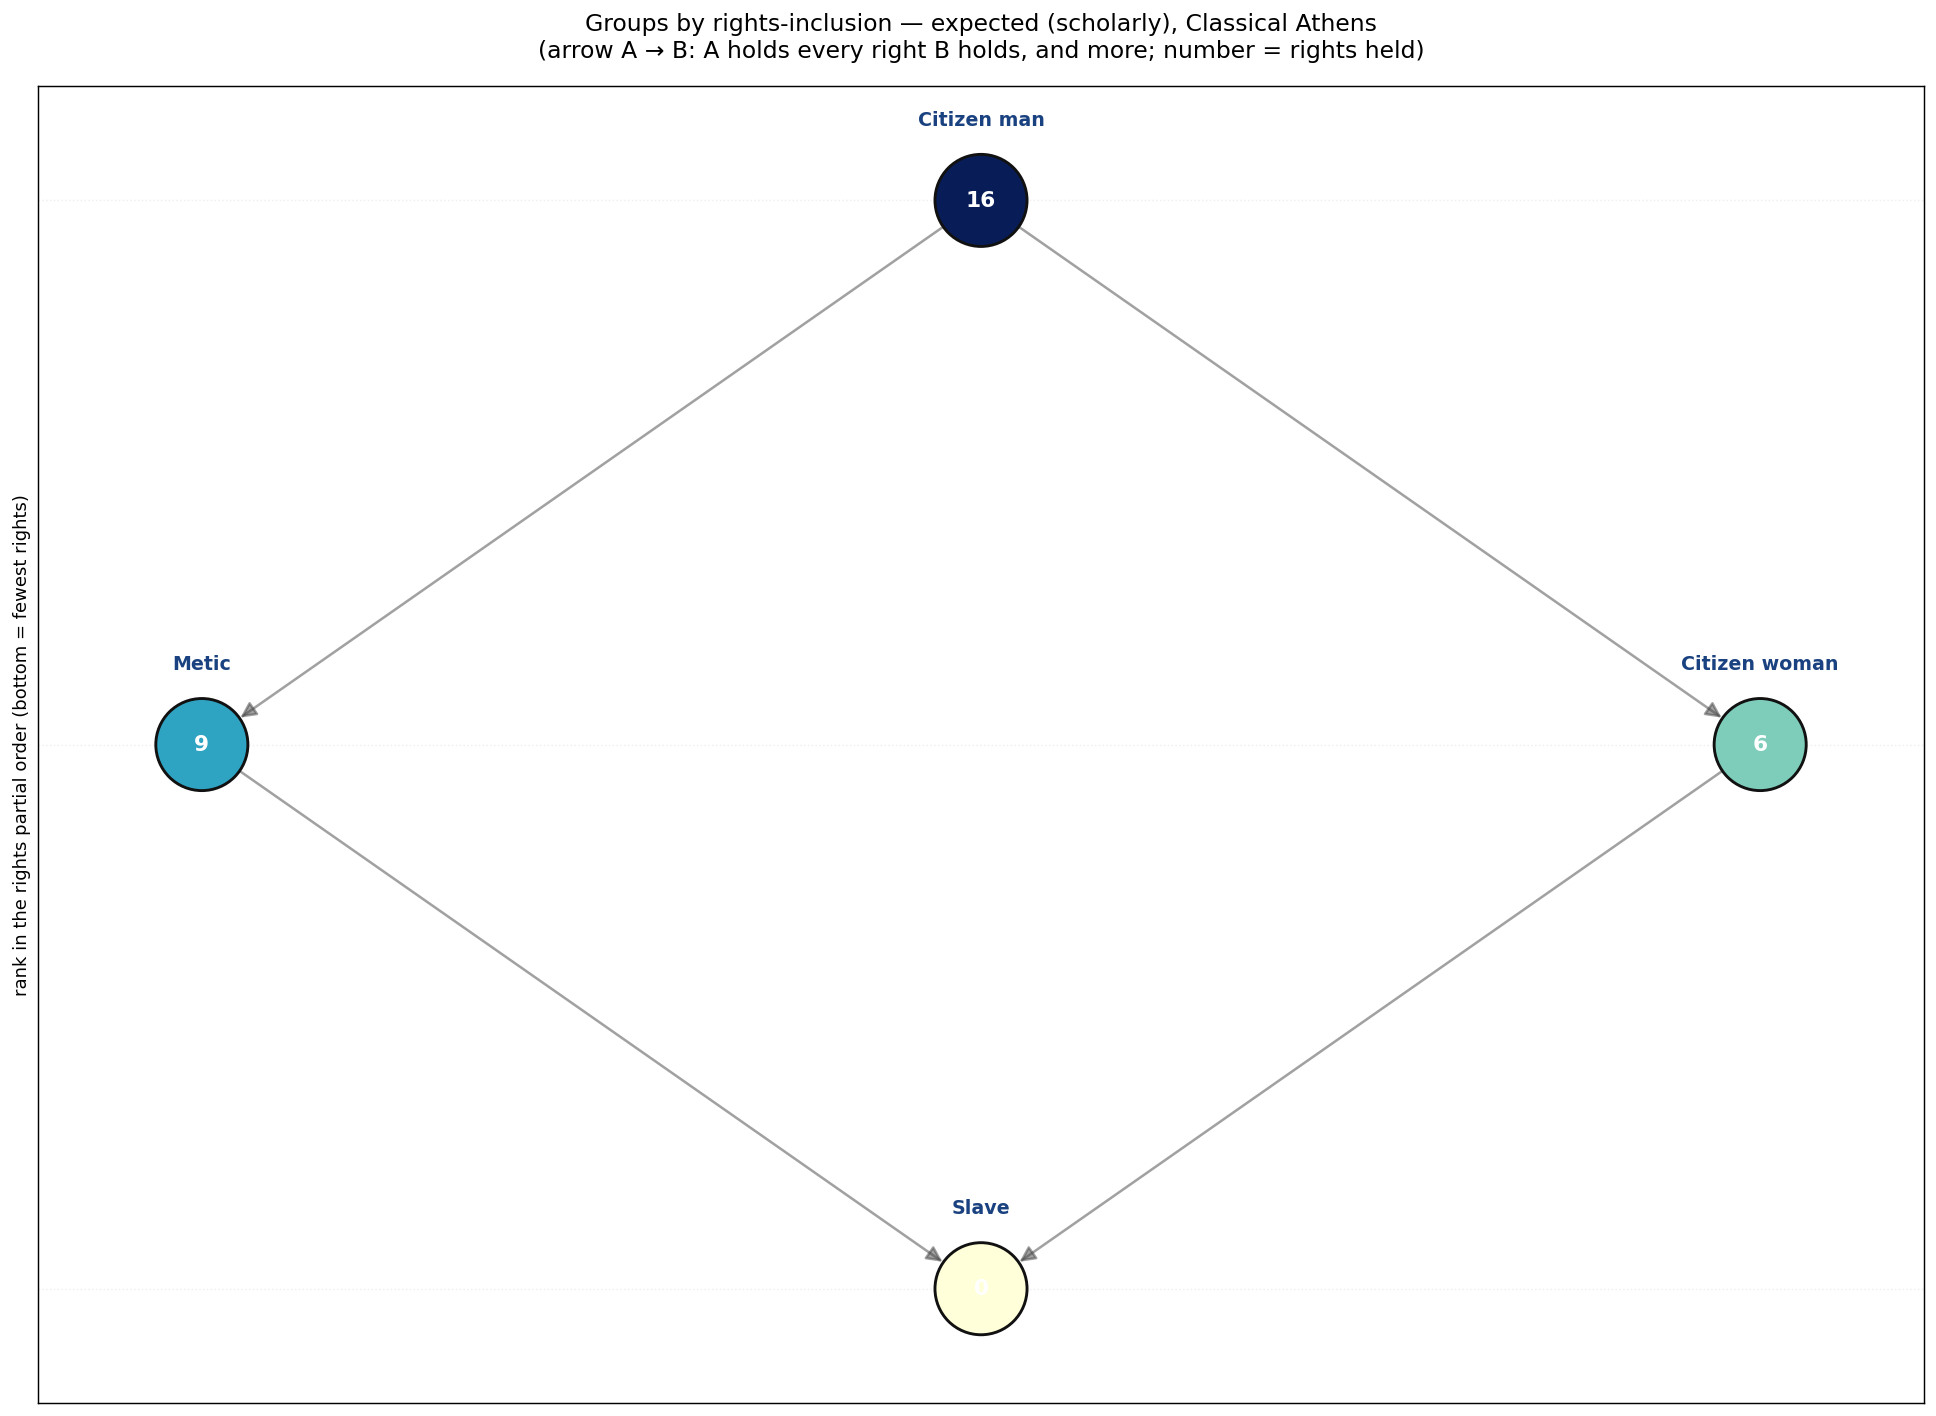

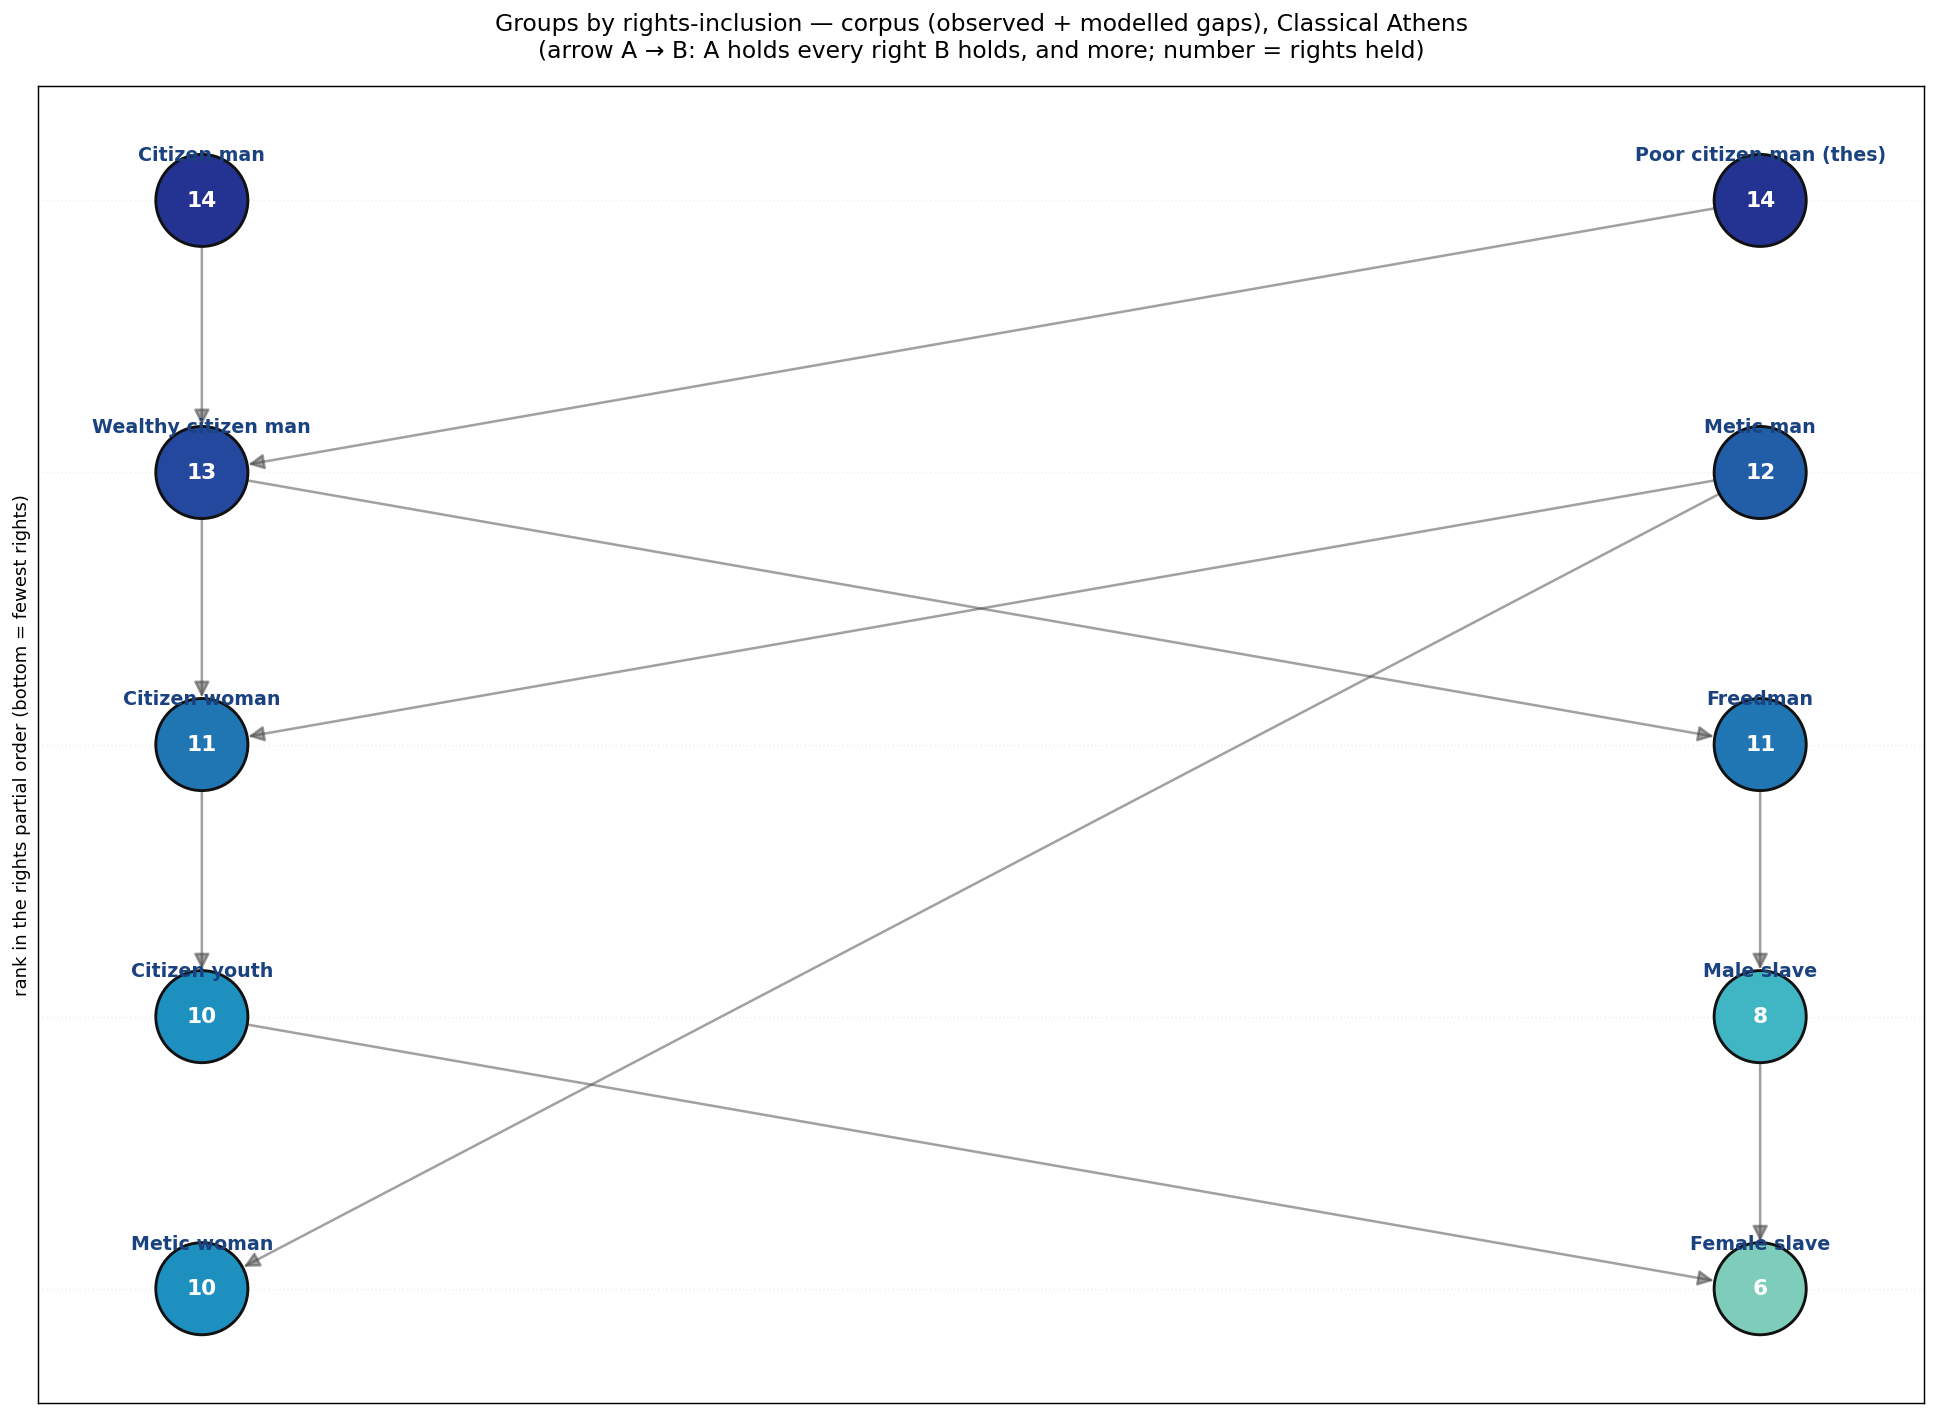

In [10]:
display(Image(str(FINAL / 'group_rights_hasse_expected.png')))
display(Image(str(FINAL / 'group_rights_hasse_corpus.png')))

**Reading.** The *expected* diagram is a clean diamond — Citizen man ⊋ {Metic, Citizen
woman} ⊋ Slave — with metic and citizen woman **incomparable** (the metic has legal and
property standing the citizen woman lacks; she has citizenship and marriage rights he
lacks). The *corpus* diagram keeps citizens on top and slaves at the bottom, but slaves
sit higher than scholarship expects (≈6–8 rights) because the corpus discusses slaves
mainly in freedom/manumission and legal contexts — the same exclusion/threat bias seen
in §6. Both are honest views: one of the world as scholarship reconstructs it, one of the
world as this corpus reports it.

## Outputs

`data/clean/final/`:

| File | What it is |
|---|---|
| **`top_cells_rights_matrix.tsv`** | The four top cells × granular rights, exception-aware. |
| `group_rights_matrix.tsv` | Full emic-group instances × granular rights (all polities). |
| `expected_rights_classical_athens.tsv` | Hand-authored scholarly benchmark + basis notes. |
| `expected_vs_observed_classical_athens.tsv` | Cell-by-cell agreement. |
| `rights_contradictions.tsv` | Residual contested cells, with sub-population explanation. |
| `right_level_diagnostic.tsv` | Comparability vs contradiction per right level. |
| `group_criteria_linking_audit.tsv` | Label-vs-text criterion agreement. |
| `rule_resource_granular.tsv` | The LLM group-independent granular right per rule. |
| `group_rights_imputed.tsv` | Complete group × rights with observed/inferred + probability (modelled gaps). |
| `group_rights_hasse_expected.png` / `_corpus.png` | Hasse diagrams (scholarly vs corpus). |

Scripts: `scripts/classifiers/classify_resource_granular.py` (LLM reclassification),
`scripts/analysis/build_group_rights_table.py`, `scripts/analysis/build_expected_rights_table.py`.